In [29]:
from collections.abc import Sequence
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import pandas as pd

from mbloodmoon.types import CoordEquatorial
from mbloodmoon.coords import shift2equatorial
from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.mask import CodedMaskCamera
from mbloodmoon.mask import encode, decode, variance, snratio
from mbloodmoon.optim import model_shadowgram

from mbloodmoon.mask import codedmask
#from temp_camera import codedmask

def _get_mask(mask: str) -> str:
    """Retrieve WFM mask pattern path."""

    if Path(base_path := "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/").is_dir():
        mask_path = base_path + "Simulations/" + mask
    elif Path(base_path := "/mnt/d/PhD_AASS/Coding/Images_fits/").is_dir():
        mask_path = base_path + mask
    else:
        raise ValueError("A0, ma ndo sei finit*?")
    
    if not Path(mask_path).is_file():
        raise ValueError(f"WFM mask '{mask}' does not exist.")

    return mask_path


@dataclass(frozen=True)
class MiniSDL:
    """Test SimulationDataLoader instance with camera pointing."""

    CAMZRA: float
    CAMZDEC: float
    CAMXRA: float
    CAMXDEC: float

    @property
    def pointings(self) -> dict[str, CoordEquatorial]:
        """
        Camera axis pointing information in equatorial frame.
        Angles are expressed in degrees.
        """
        return {
            "z": CoordEquatorial(ra=self.CAMZRA, dec=self.CAMZDEC),
            "x": CoordEquatorial(ra=self.CAMXRA, dec=self.CAMXDEC),
        }


def generate_detector(
    camera: CodedMaskCamera,
    record: np.recarray,
    exposure: float,
    vignetting: bool,
    psfy: bool,
    bkg: bool = False,
) -> np.array:
    """Generates the decoded sky for the given sources."""
    # Crab flux [ph/cm2/s]
    Crab = 4.55
    # CXB flux [ph/cm2/s]
    bkg_rate = 1.27
    # Detector AREA [cm2]
    px_area = 1e-2 * camera.specs["mask_deltax"] * camera.specs["mask_deltay"]
    area_detector = (
        px_area / np.prod(camera.upscale_f) * camera.bulk.sum()
    )

    def compute_fluence(flux: float, area: float, t: float) -> float:
        """Computes source fluence."""
        return flux * Crab * area * t

    base_sky = (
        np.zeros(camera.shape_sky) if not bkg
        else 0.25 * np.random.poisson(bkg_rate * px_area * exposure, camera.shape_sky)
    )
    detector = encode(
        camera=camera,
        sky=base_sky,
    )

    for sx, sy, f in zip(
        record["SHIFTX"],
        record["SHIFTY"],
        record["FLUX"],
    ):
        fluence = compute_fluence(
            flux=f,
            area=area_detector,
            t=exposure,
        )
        detector += model_shadowgram(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            vignetting=vignetting,
            psfy=psfy,
        ) * fluence
    
    return detector


def make_record(
    shifts_x: Sequence[float],
    shifts_y: Sequence[float],
    IDs: Sequence[str],
    fluxes: float | Sequence[float],
    sdl: SimulationDataLoader,
    camera: CodedMaskCamera,
) -> np.recarray:
    """Builds the sources record structure."""
    rec = np.rec.array(
        obj=[
            (name, sx, sy, *shift2equatorial(sdl, camera, sx, sy), f)
            for name, sx, sy, f in zip(IDs, shifts_x, shifts_y, fluxes)
        ],
        dtype=[
            ('ID', 'U10'), ('SHIFTX', 'f8'), ('SHIFTY', 'f8'),
            ('RA', 'f8'), ('DEC', 'f8'), ('FLUX', 'f8'),
        ],
    )
    return rec


def make_catalog(
    record: np.recarray,
    save_to: str | Path | None = None,
) -> None:
    """Creates the catalog for the WISEMAN simulator."""
    df = pd.DataFrame(record)
    if save_to is not None:
        df.to_csv(path_or_buf=save_to, index=False)
    return df


RCPARAMS = {
    'font.family': 'sans-serif',
    'font.weight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}
PCAM = {
    "sourcename_fs": 6,
    "title_fs": 12,
    "title_pad": 8,
    "txt_fw": "bold",
    "txt_color": "white",
}
mpl.rcParams.update(RCPARAMS)


def show_skyfield(
    sources: np.recarray,
    camera: CodedMaskCamera,
    show_info: bool = True,
) -> None:
    """Plots the sky binning structure and the specified sources."""
    skyx, skyy = camera.bins_sky

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    fig.tight_layout()
    ax.add_patch(patches.Rectangle((skyx[0], skyy[0]), skyx[-1] - skyx[0], skyy[-1] - skyy[0], linewidth=1, edgecolor='k', facecolor='k'))
    ax.plot((skyx[0], skyx[-1]), (0, 0), color='r', linestyle='dashdot', linewidth=0.75, alpha=0.3)
    ax.plot((0, 0), (skyy[0], skyy[-1]), color='r', linestyle='dashdot', linewidth=0.75, alpha=0.3)
    ax.scatter(sources["SHIFTX"], sources["SHIFTY"], color="LawnGreen", marker="+", alpha=0.75, s=15, label="sources")

    if show_info:
        for name, shiftx, shifty, ra, dec in zip(
            sources["ID"], sources["SHIFTX"], sources["SHIFTY"], sources["RA"], sources["DEC"],
        ):
            #ax.text(
            #    shiftx - 18, shifty + 5, f"RA: {ra:.4f}\nDEC: {dec:.4f}", color=PCAM["txt_color"],
            #    fontsize=PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
            #)
            ax.text(
                shiftx, shifty - 7, name, color=PCAM["txt_color"],
                fontsize=PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
            )

    plt.xlim((skyx[0], skyx[-1]))
    plt.ylim((skyy[0], skyy[-1]))
    ax.set_xlabel("x bins [mm]", fontsize=12, fontweight='bold')
    ax.set_ylabel("y bins [mm]", fontsize=12, fontweight='bold')
    ax.set_title("Camera Binning Grid", fontsize=14, pad=8, fontweight='bold')
    ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2)
    ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.legend(loc='best')
    plt.show()

In [14]:
mask_FITS = "wfm_mask.fits"
mask_path = _get_mask(mask_FITS)

UPX, UPY = 3, 5

wfm = codedmask(mask_path, UPX, UPY)
sdl = MiniSDL(
    CAMZRA=266.4,
    CAMZDEC=-28.94,
    CAMXRA=266.4,
    CAMXDEC=61.06,
)

skyx, skyy = wfm.bins_sky

In [ ]:
from mbloodmoon.coords import shift2angle, angle2shift

N = 30

min_thetax, max_thetax = -40, 40 # shift2angle(wfm, skyx[0]), shift2angle(wfm, skyx[-1])
anglesx = np.random.uniform(min_thetax, max_thetax, size=N)

min_thetay, max_thetay = -40, 40 # shift2angle(wfm, skyy[0]), shift2angle(wfm, skyy[-1])
anglesy = np.random.uniform(min_thetay, max_thetay, size=N)


x, y = angle2shift(wfm, anglesx), angle2shift(wfm, anglesy)

In [33]:
t = np.array([
    -75.28431102, -20.72496551, -145.69172015, -58.73047192, -27.0226492 , -136.81466483, 
    -17.90813954, -32.98621252, 157.98597019, -98.45742364, -156.19118927, 73.04625453, 
    40.99435959, 121.90456792, 30.88487237, 159.08675341, -35.95930563, -95.99253138,  
    24.98154339, -146.05161604, -63.92086292, 71.69063089, -122.47557867, -28.36243499,
    -71.87242672, -154.26855762, -56.0912672 , -42.99225956, -37.03675654, 136.13076287,
])

w = np.array([
    86.81417403, 88.81401139, -57.84757712, -56.20447768,
    13.28941439, -50.71489961, 137.11070711, 148.75797241,
    -153.42045973, -13.21209337, 0.79926323, 120.13175226,
    45.59024961, 139.79312938, -21.88917417, 58.64827511,
    122.33784019, 161.29542014, -97.31311873, 169.34659465,
    70.59902568, -22.30884067, 82.22669013, -29.47703795,
    -80.21023616, -112.01498654, -149.73715355, -51.99192767,
    49.04787544, 7.53718268,
])

Sources: 30


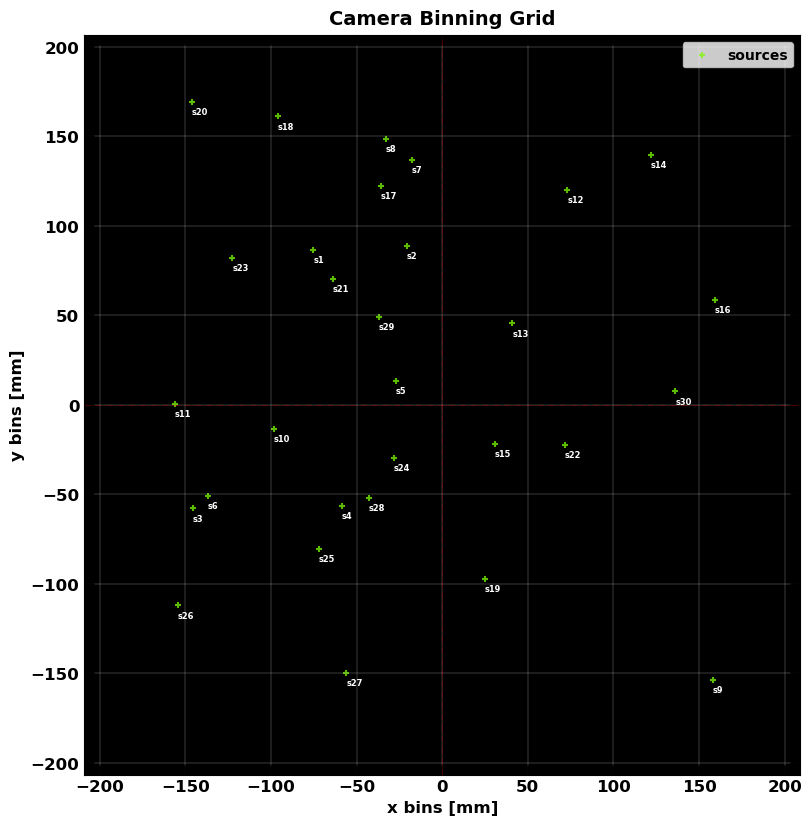

In [38]:
names = np.array([f"s{idx + 1}" for idx in range(len(y))])
fluxes = 1 * np.ones(len(y))
#fluxes[4] = 1
print(f"Sources: {len(y)}")

rec = make_record(
    shifts_x=t,
    shifts_y=w,
    IDs=names,
    fluxes=fluxes,
    sdl=sdl,
    camera=wfm,
)

show_skyfield(
    sources=rec,
    camera=wfm,
    show_info=True,
)

In [21]:
exposure = 1e3
vignetting = True
psfy = False
bkg = False

detector = generate_detector(
    camera=wfm,
    record=rec,
    exposure=exposure,
    vignetting=vignetting,
    psfy=psfy,
    bkg=bkg,
)

expected_sky = decode(camera=wfm, detector=detector)
significance = snratio(
    sky=expected_sky,
    var=np.clip(variance(wfm, detector), a_min=1, a_max=None),
)

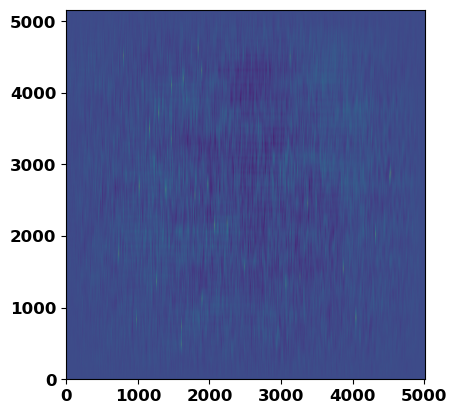

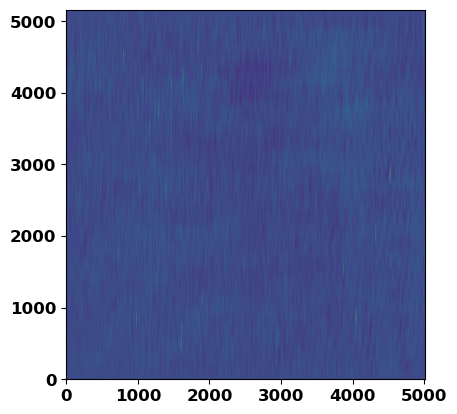

In [22]:
plt.imshow(expected_sky, origin="lower")
plt.show()

plt.imshow(significance, origin="lower")
plt.show()

In [15]:
record_path = "/home/edoardo/Desktop/" + "catalog_noCXB_1Crab.csv"
df = make_catalog(record=rec, save_to=None)

df

,ID,SHIFTX,SHIFTY,RA,DEC,FLUX
0,s0,0.000000,165.48,223.438453,-22.030637,1.0
1,s1,0.000000,124.12,231.465619,-24.385052,1.0
2,s2,0.000000,82.76,241.426574,-26.621996,1.0
3,s3,0.000000,41.40,253.284955,-28.303273,1.0
4,s4,0.000000,0.00,266.400000,-28.940000,1.0
5,s5,41.541667,0.00,266.400000,-17.377510,1.0
6,s6,83.291667,0.00,266.400000,-6.636427,1.0
7,s7,125.041667,0.00,266.400000,2.685473,1.0
8,s8,166.791667,0.00,266.400000,10.460761,1.0


In [17]:
from mbloodmoon.coords import shift2pos
from mbloodmoon.images import argmax

print(
    f"Max significance: {significance.max()}\n"
    f"Max SNR pos: {argmax(significance)}\n"
)

for name, sx, sy in zip(df["ID"], df["SHIFTX"], df["SHIFTY"]):
    print(
        f"# - Source {name.upper()}\n"
        f"  - significance: {significance[*shift2pos(wfm, sx, sy)]}\n"
        f"  - pos: {shift2pos(wfm, sx, sy)}\n"
    )

Max significance: 687.6551749980491
Max SNR pos: (4653, 2507)

# - Source S0
  - significance: 687.6551749980491
  - pos: (4653, 2507)

# - Source S1
  - significance: 602.1841499170761
  - pos: (4136, 2507)

# - Source S2
  - significance: 534.2002570278211
  - pos: (3619, 2507)

# - Source S3
  - significance: 543.5655432031398
  - pos: (3102, 2507)

# - Source S4
  - significance: 485.6264299070984
  - pos: (2584, 2507)

# - Source S5
  - significance: 443.375842378484
  - pos: (2584, 3006)

# - Source S6
  - significance: 491.7550243655857
  - pos: (2584, 3507)

# - Source S7
  - significance: 492.5790555956426
  - pos: (2584, 4008)

# - Source S8
  - significance: 570.3873779711611
  - pos: (2584, 4509)

